In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from routes_preprocessing import *

In [3]:
# Last file of 2024 used for testing and analytics
filename = "../datasets/MBTA_Bus_Arrival_Departure_Times_2024/MBTA-Bus-Arrival-Departure-Times_2024-12.csv"

In [25]:
# headway times for 2024 season, want to load and concatenate all fall months
for month in ["09", "10", "11", "12"]:
    filename = f'../datasets/MBTA_Bus_Arrival_Departure_Times_2024/MBTA-Bus-Arrival-Departure-Times_2024-{month}.csv'
    df = pd.read_csv(filename)
    if month == "09":
        df_2024 = df
    else:
        df_2024 = pd.concat([df_2024, df])

In [26]:
df = df_2024

In [27]:
print("before dropping headway NaN:", len(df))

df = df.dropna(subset=['scheduled_headway'])
df = df.dropna(subset=['headway'])


print("after dropping headway NaN:", len(df))


before dropping headway NaN: 9081106
after dropping headway NaN: 3634046


In [28]:
df.head()

,service_date,route_id,direction_id,half_trip_id,stop_id,time_point_id,time_point_order,point_type,standard_type,scheduled,actual,scheduled_headway,headway
7,2024-09-01,01,Inbound,64239964.0,110,hhgat,1,Startpoint,Headway,1900-01-01T11:25:00Z,1900-01-01T11:24:58Z,1200.0,1177.0
8,2024-09-01,01,Inbound,64239964.0,67,maput,2,Midpoint,Headway,1900-01-01T11:29:00Z,1900-01-01T11:27:02Z,1200.0,1205.0
11,2024-09-01,01,Inbound,64239964.0,72,cntsq,3,Midpoint,Headway,1900-01-01T11:32:00Z,1900-01-01T11:29:35Z,1200.0,1192.0
12,2024-09-01,01,Inbound,64239964.0,75,mit,4,Midpoint,Headway,1900-01-01T11:35:00Z,1900-01-01T11:33:28Z,1200.0,1155.0
13,2024-09-01,01,Inbound,64239964.0,79,hynes,5,Midpoint,Headway,1900-01-01T11:39:00Z,1900-01-01T11:35:39Z,1200.0,1066.0


In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime format
df['actual'] = pd.to_datetime(df['actual'])
df['service_date'] = pd.to_datetime(df['service_date'])

key_routes = {"01", "15", "22", "23", "28", "32", "39", "57", "66", "71", "73", "77", "111", "116", "117"}

# https://mbta-massdot.opendata.arcgis.com/documents/c4625d2f71bc4b638ade0e2015851c00/explore
# MBTA calculates service days from 3:00 AM to 2:59 AM the next day, so we need to adjust the actual column by 3 hours to get the correct service time
# This is important if we want to examine headway on weekdays at peak hours 
df['adjusted_actual'] = df['actual'] - pd.Timedelta(hours=3)


df['half_hour_bin'] = df['adjusted_actual'].dt.floor('30min')
df['hour'] = df['adjusted_actual'].dt.hour



df_filtered = df[
    (df['headway'].notna()) &
    (df['service_date'].dt.year == 2024) &
    (df['service_date'].dt.weekday < 5) &  
    (df['route_id'].isin(key_routes))
]



C:\Users\Michael\AppData\Local\Temp\ipykernel_8936\1718586349.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  xticks = pd.date_range(start='1900-01-01 06:00', end='1900-01-01 23:00', freq='1H')


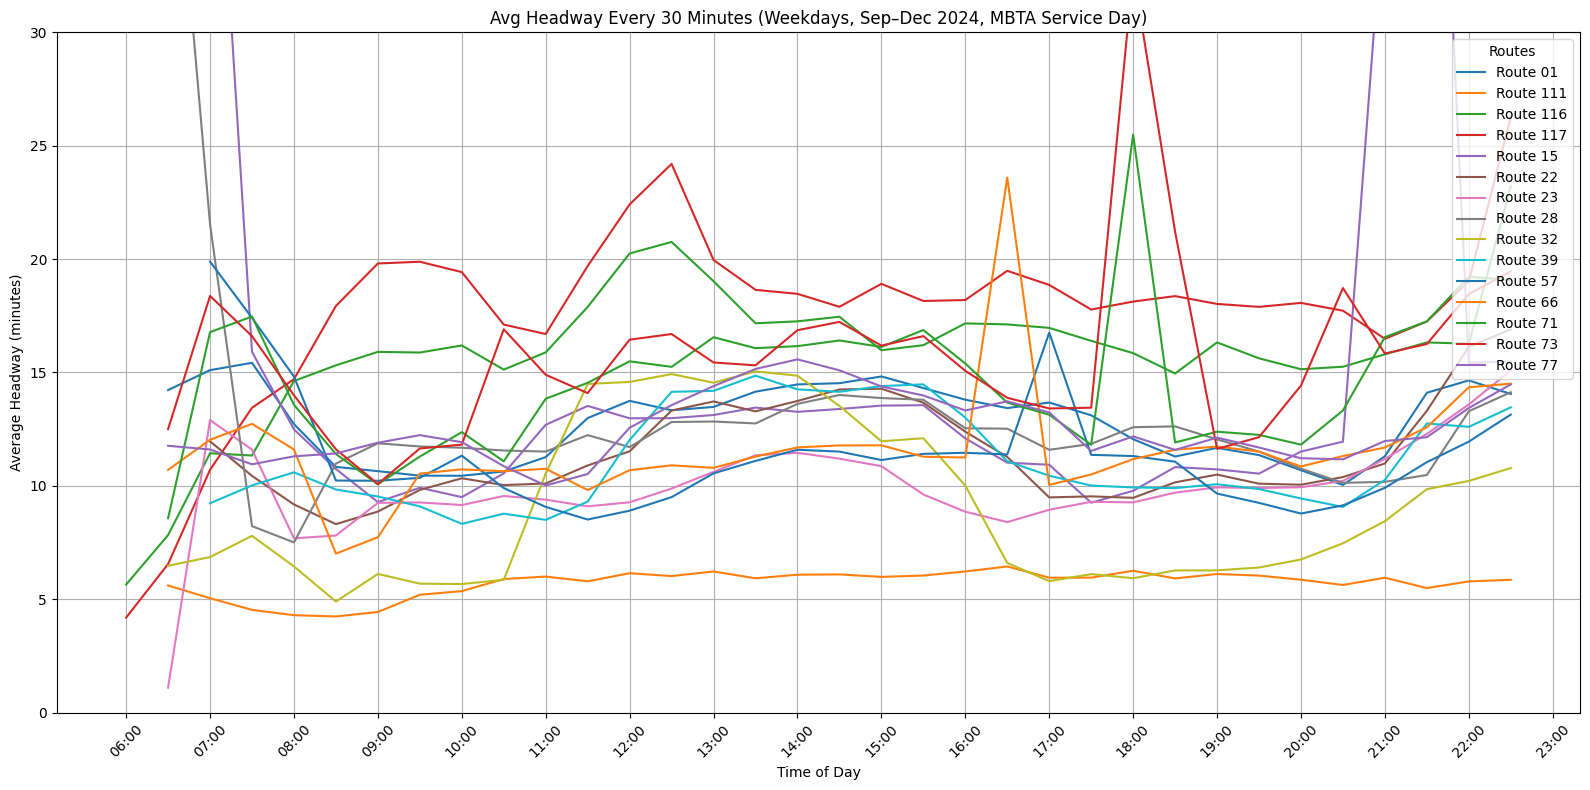

In [52]:
plt.figure(figsize=(16, 8))

# Plot each route
for route in sorted(key_routes):
    route_data = df_filtered[df_filtered['route_id'] == route]
    if route_data.empty:
        continue
    avg_headway = (
        route_data
        .groupby('half_hour_bin')['headway']
        .mean()
        .reset_index()
    )
    avg_headway['avg_headway_minutes'] = avg_headway['headway'] / 60
    
    # Filter time window from 6:00 to 23:00
    plot_data = avg_headway[
        (avg_headway['half_hour_bin'].dt.hour >= 6) &
        (avg_headway['half_hour_bin'].dt.hour < 23)
    ]
    
    plt.plot(plot_data['half_hour_bin'], plot_data['avg_headway_minutes'], label=f'Route {route}')


xticks = pd.date_range(start='1900-01-01 06:00', end='1900-01-01 23:00', freq='1H')
plt.xticks(xticks, [t.strftime('%H:%M') for t in xticks], rotation=45)


# Final plot settings
plt.title('Avg Headway Every 30 Minutes (Weekdays, Sep–Dec 2024, MBTA Service Day)')
plt.xlabel('Time of Day')
plt.ylabel('Average Headway (minutes)')
plt.ylim(0, 30)
plt.grid(True)
plt.legend(title="Routes", loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
